# 🧠 CNN Image Classification using MNIST Dataset

This project implements a Convolutional Neural Network (CNN) using TensorFlow/Keras to classify handwritten digit images from the MNIST dataset.

The project includes:
- CNN architecture
- Data augmentation
- Accuracy tracking
- Loss visualization
- Custom image prediction

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report

In [21]:
# Load MNIST dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images Shape:", X_train.shape)

print("Testing Images Shape:", X_test.shape)

warnings.filterwarnings("ignore")

Training Images Shape: (60000, 28, 28)
Testing Images Shape: (10000, 28, 28)


### Observation:
The MNIST dataset contains grayscale handwritten digit images of size 28×28 pixels.

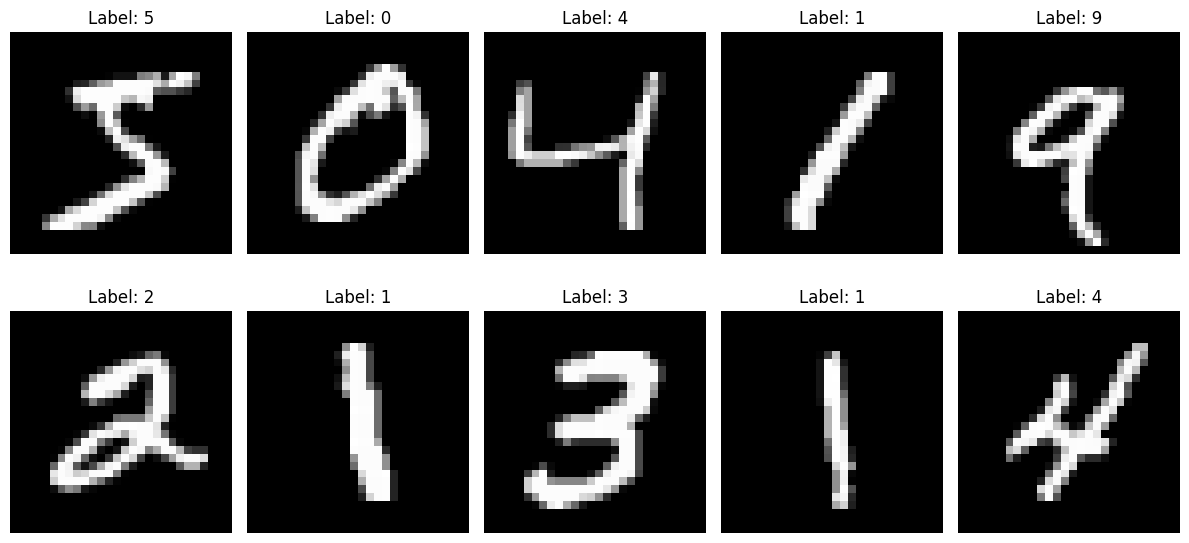

In [22]:
# Display sample images

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        X_train[i],
        cmap='gray'
    )

    plt.title(
        f"Label: {y_train[i]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

### Observation:
The dataset contains handwritten digits from 0 to 9 with varying writing styles.

In [23]:
# Normalize pixel values

X_train = X_train / 255.0

X_test = X_test / 255.0

### Observation:
Pixel values were normalized between 0 and 1 to improve model convergence and training stability.

In [24]:
# Reshape images

X_train = X_train.reshape(
    -1,
    28,
    28,
    1
)

X_test = X_test.reshape(
    -1,
    28,
    28,
    1
)

print(X_train.shape)

(60000, 28, 28, 1)


### Observation:
Images were reshaped into 4D tensors to match CNN input requirements.

In [25]:
# Convert labels into categorical

y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

### Observation:
Class labels were converted into one-hot encoded vectors for multiclass classification.

In [26]:
# Data augmentation

datagen = ImageDataGenerator(

    rotation_range=10,

    zoom_range=0.1,

    width_shift_range=0.1,

    height_shift_range=0.1
)

datagen.fit(X_train)

### Observation:
Data augmentation artificially increased dataset diversity and reduced overfitting.

In [27]:
# CNN Model

model = Sequential()

# First Convolution Layer

model.add(

    Conv2D(

        32,

        (3,3),

        activation='relu',

        input_shape=(28,28,1)
    )
)

model.add(

    MaxPooling2D(
        pool_size=(2,2)
    )
)

# Second Convolution Layer

model.add(

    Conv2D(

        64,

        (3,3),

        activation='relu'
    )
)

model.add(

    MaxPooling2D(
        pool_size=(2,2)
    )
)

# Flatten

model.add(
    Flatten()
)

# Dense Layer

model.add(

    Dense(
        128,
        activation='relu'
    )
)

# Dropout

model.add(
    Dropout(0.5)
)

# Output Layer

model.add(

    Dense(
        10,
        activation='softmax'
    )
)

# Model Summary

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Observation:
The CNN model extracts spatial image features using convolution and pooling layers before classification through dense layers.

In [28]:
# Compile model

model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [29]:
# Train model

history = model.fit(

    datagen.flow(
        X_train,
        y_train,
        batch_size=64
    ),

    epochs=10,

    validation_data=(
        X_test,
        y_test
    )
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 78s 78ms/step - accuracy: 0.8565 - loss: 0.4488 - val_accuracy: 0.9816 - val_loss: 0.0560
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.9444 - loss: 0.1839 - val_accuracy: 0.9866 - val_loss: 0.0356
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 72s 77ms/step - accuracy: 0.9737 - loss: 0.0902 - val_accuracy: 0.9928 - val_loss: 0.0200
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 82ms/step - accuracy: 0.9773 - loss: 0.0786 - val_accuracy: 0.9919 - val_loss: 0.0258
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 81ms/step - accuracy: 0.9806 - loss: 0.0663 - val_accuracy: 0.9926 - val_loss: 0.0205


### Observation:
The CNN model learned image patterns effectively through iterative training and validation.

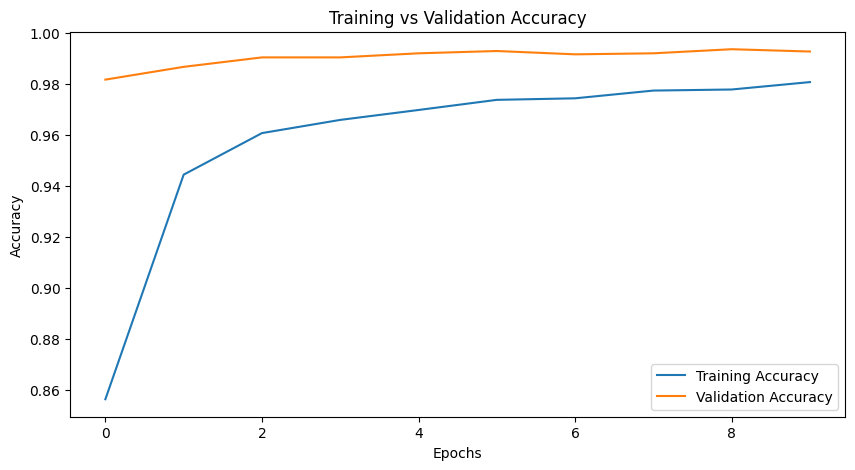

In [30]:
# Plot accuracy

plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    "Training vs Validation Accuracy"
)

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

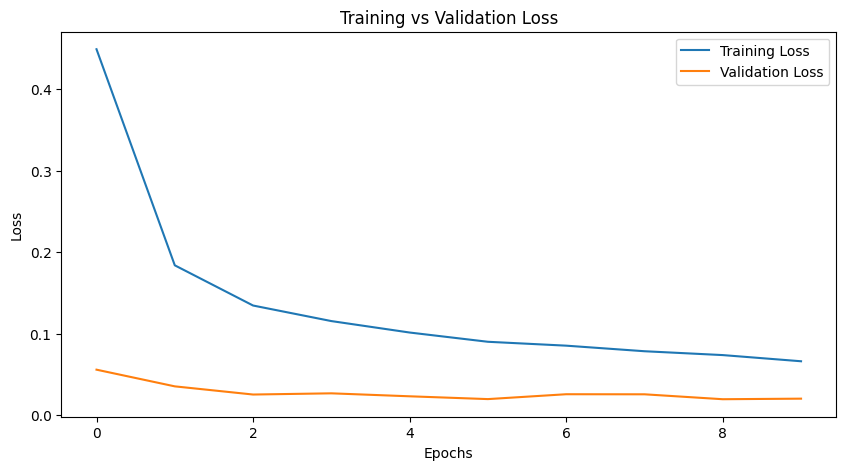

In [31]:
# Plot loss

plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    "Training vs Validation Loss"
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()

### Observation:
Training accuracy increased while loss decreased, indicating effective learning and model convergence.

In [32]:
# Evaluate model

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9926 - loss: 0.0205
Test Accuracy: 0.9926000237464905


### Observation:
The trained CNN model achieved high classification accuracy on unseen handwritten digit images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


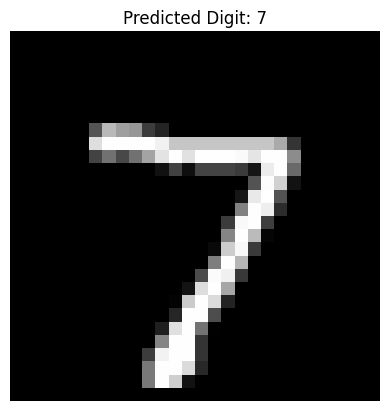

In [33]:
# Predict sample image

prediction = model.predict(
    X_test[:1]
)

predicted_class = np.argmax(
    prediction
)

plt.imshow(
    X_test[0].reshape(28,28),
    cmap='gray'
)

plt.title(
    f"Predicted Digit: {predicted_class}"
)

plt.axis('off')

plt.show()

In [34]:
# Classification report

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

y_true = np.argmax(
    y_test,
    axis=1
)

print(

    classification_report(
        y_true,
        y_pred_classes
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [35]:
# Save model

model.save(
    "cnn_mnist_model.h5"
)

print("Model Saved Successfully")

Model Saved Successfully


### Observation:
The trained CNN model was saved for future deployment and real-time prediction.

# ✅ Conclusion

This project successfully implemented a CNN-based handwritten digit recognition system using TensorFlow/Keras.

The model achieved high accuracy through:
- Convolutional Neural Networks
- Data augmentation
- Feature extraction
- Deep learning optimization

The system can classify both dataset images and custom uploaded images effectively.